# Module 2, Class 3 Assignment: Data Visualization and Trend Analysis

**Student:** Firdavs Boliev

This notebook uses the cleaned Superstore dataset from Class 2 to build distribution plots, category comparisons, outlier checks, a correlation heatmap, and a monthly sales trend.

## Setup: Load Cleaned Superstore Data

The notebook first looks for `superstore_cleaned.csv` in common local paths. This keeps the notebook usable both inside this repository and in Google Colab after uploading the CSV.

In [1]:
# Import the libraries used for data analysis and visualization.
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

possible_paths = [
    Path("superstore_cleaned.csv"),
    Path("../superstore_cleaned.csv"),
    Path("../../class_2/superstore_cleaned.csv"),
    Path("../../class_2/submissions/superstore_cleaned.csv"),
]

data_path = None
for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Upload superstore_cleaned.csv or place it in module-2/class_2.")

df = pd.read_csv(data_path)
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print(f"Loaded {data_path}")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded ..\..\class_2\superstore_cleaned.csv
Shape: 9994 rows, 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Task 1: Distribution Plots

The Sales histogram shows how order-line sales values are distributed. The Profit boxplot shows the middle range and the outliers.

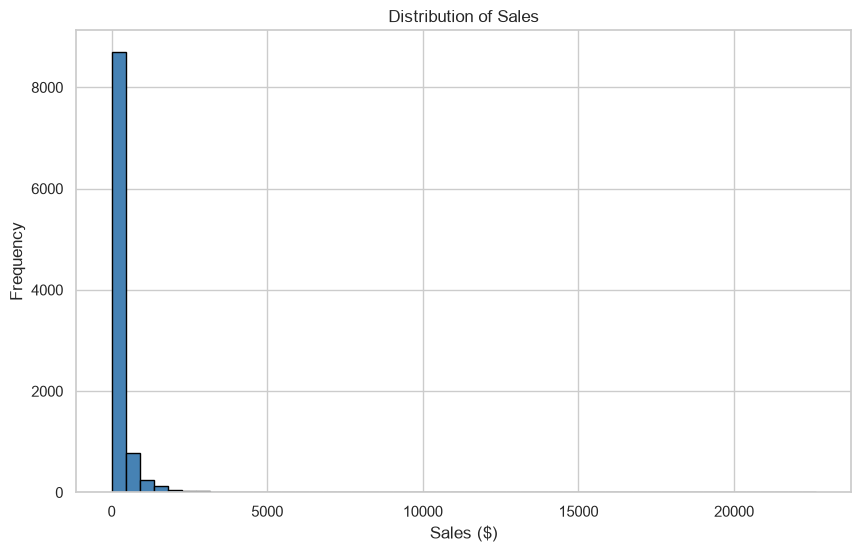

In [2]:
# Plot a histogram to see the shape of the Sales distribution.
plt.figure(figsize=(10, 6))
plt.hist(df["Sales"], bins=50, color="steelblue", edgecolor="black")
plt.title("Distribution of Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Frequency")
plt.show()

### Sales Histogram Interpretation

The Sales distribution is strongly right-skewed. Most order lines are small purchases, while a smaller number of large purchases create a long tail on the right side.

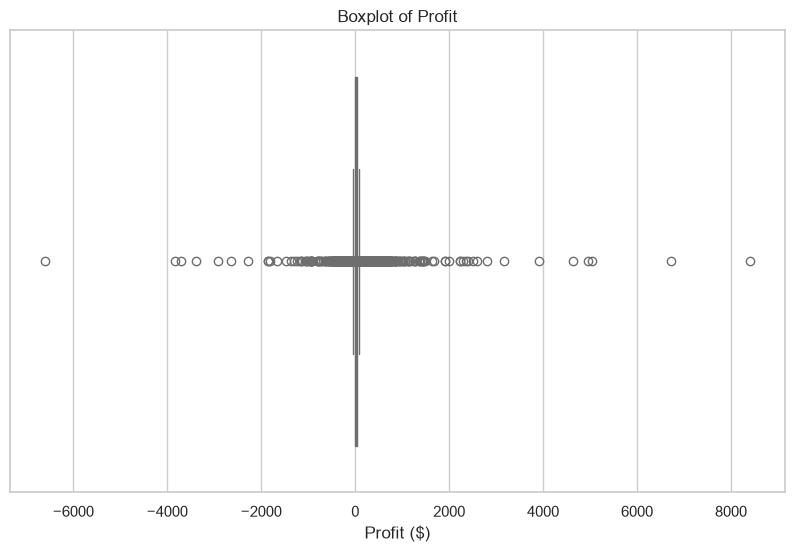

In [3]:
# Plot a boxplot to see the spread and outliers in Profit.
plt.figure(figsize=(10, 6))
sns.boxplot(x=df["Profit"], color="lightcoral")
plt.title("Boxplot of Profit")
plt.xlabel("Profit ($)")
plt.show()

### Profit Boxplot Interpretation

Most profit values are close to the center of the plot, but there are visible outliers on both the loss side and the high-profit side. This means some products or orders behave very differently from typical transactions.

## Task 2: Category-Wise Trends

These bar charts compare total sales across product categories and regions.

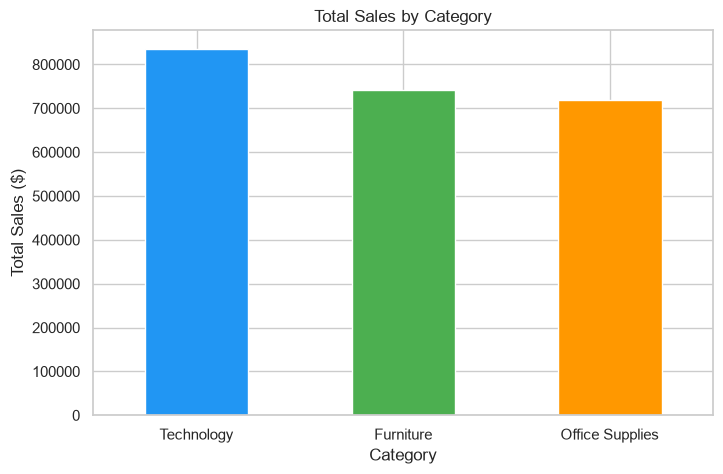

Category
Technology         836154.03
Furniture          741999.80
Office Supplies    719047.03
Name: Sales, dtype: float64


In [4]:
# Group by Category and plot total sales.
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
category_sales.plot(kind="bar", color=["#2196F3", "#4CAF50", "#FF9800"])
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.show()

print(category_sales.round(2))

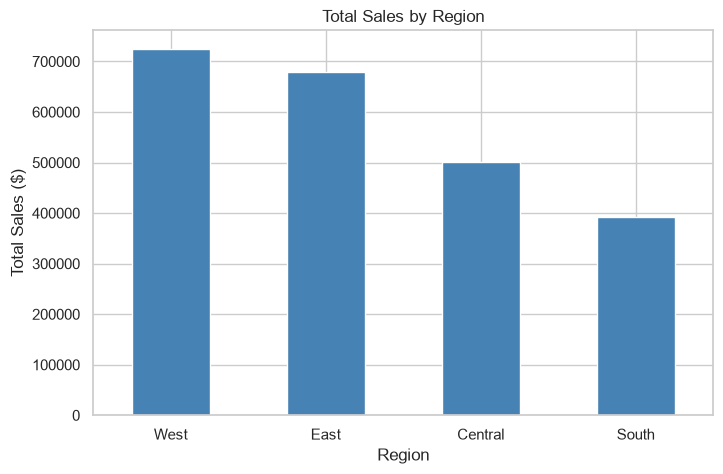

Region
West       725457.82
East       678781.24
Central    501239.89
South      391721.90
Name: Sales, dtype: float64


In [5]:
# Group by Region and plot total sales.
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_sales.plot(kind="bar", color="steelblue")
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.show()

print(region_sales.round(2))

### Category and Region Interpretation

Technology generates the most revenue among the three categories. The West region has the highest total sales, while the South region has the lowest total sales in this dataset.

## Task 3: Outlier Identification

The IQR method marks values as outliers when they are far below Q1 or far above Q3.

In [6]:
# Use the IQR method to identify Profit outliers.
q1 = df["Profit"].quantile(0.25)
q3 = df["Profit"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df["Profit"] < lower_bound) | (df["Profit"] > upper_bound)]
high_profit_outliers = (outliers["Profit"] > upper_bound).sum()
high_loss_outliers = (outliers["Profit"] < lower_bound).sum()

print(f"Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
print(f"Number of outliers: {len(outliers)} out of {len(df)} rows ({len(outliers) / len(df) * 100:.1f}%)")
print(f"High-profit outliers: {high_profit_outliers}")
print(f"High-loss outliers: {high_loss_outliers}")

Q1: 1.73, Q3: 29.36, IQR: 27.64
Lower bound: -39.72, Upper bound: 70.82
Number of outliers: 1881 out of 9994 rows (18.8%)
High-profit outliers: 1277
High-loss outliers: 604


### Outlier Interpretation

The IQR method finds both unusually high-profit and unusually high-loss rows. I would not remove these automatically because they may represent important business cases such as bulk purchases, heavy discounts, or unprofitable products.

## Task 4: Correlation Heatmap

Correlation values range from -1 to 1. Positive values move together, negative values move in opposite directions, and values near 0 have weak linear relationship.

          Sales  Quantity  Discount  Profit
Sales      1.00      0.20     -0.03    0.48
Quantity   0.20      1.00      0.01    0.07
Discount  -0.03      0.01      1.00   -0.22
Profit     0.48      0.07     -0.22    1.00


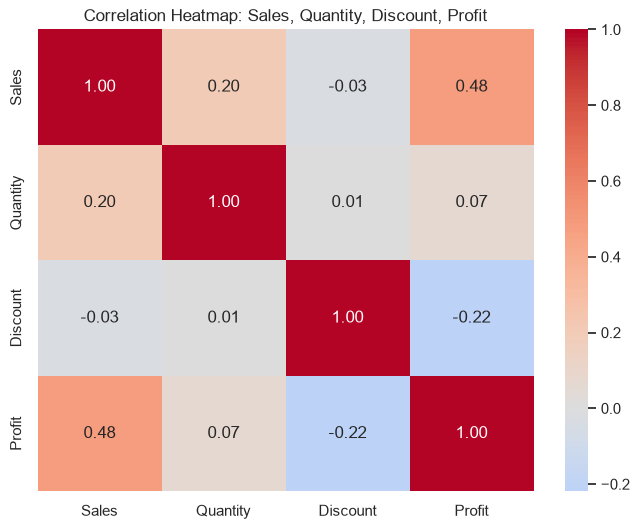

In [7]:
# Compute and plot correlations for the main numeric business columns.
numerical_cols = df[["Sales", "Quantity", "Discount", "Profit"]]
corr_matrix = numerical_cols.corr()

print(corr_matrix.round(2))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap: Sales, Quantity, Discount, Profit")
plt.show()

### Correlation Interpretation

Sales and Profit have the strongest positive relationship among these variables. Discount and Profit have a negative relationship, suggesting that heavier discounts are often connected with lower profit, but correlation alone does not prove that discounts cause the lower profit.

## Task 5: Monthly Sales Trend

This line chart groups order rows into monthly total sales so we can see changes over time.

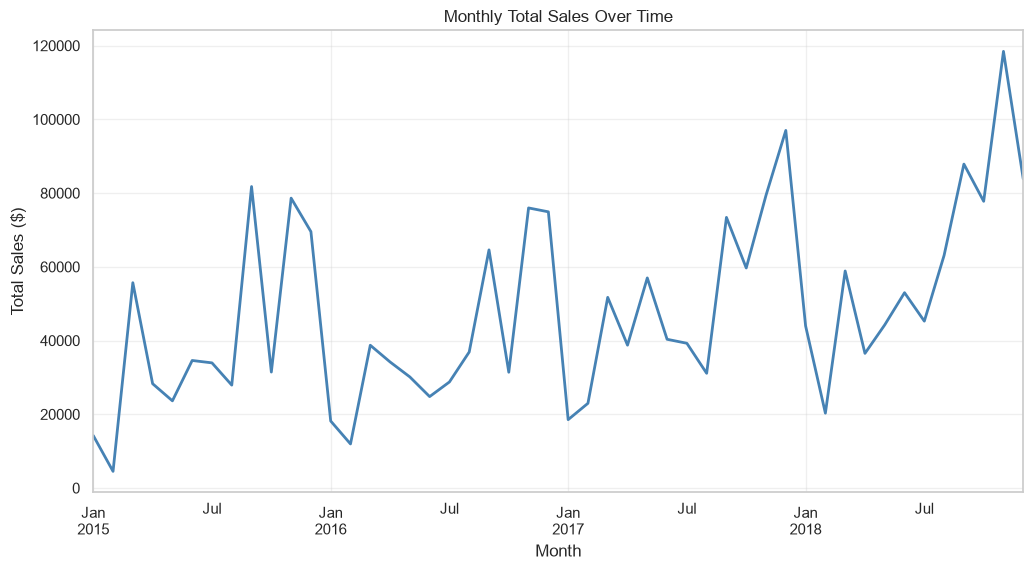

Order Date
2018-01-31     43971.37
2018-02-28     20301.13
2018-03-31     58872.35
2018-04-30     36521.54
2018-05-31     44261.11
2018-06-30     52981.73
2018-07-31     45264.42
2018-08-31     63120.89
2018-09-30     87866.65
2018-10-31     77776.92
2018-11-30    118447.82
2018-12-31     83829.32
Freq: ME, Name: Sales, dtype: float64


In [8]:
# Resample order data into month-end total sales and plot the trend.
monthly_sales = df.resample("ME", on="Order Date")["Sales"].sum()

plt.figure(figsize=(12, 6))
monthly_sales.plot(color="steelblue", linewidth=2)
plt.title("Monthly Total Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.grid(True, alpha=0.3)
plt.show()

print(monthly_sales.tail(12).round(2))

### Monthly Trend Interpretation

Sales move up and down by month, with several noticeable spikes near the end of the year. As a store manager, I would prepare inventory and promotions before the stronger months instead of reacting after demand already increases.

## Task 6: Reflection Questions

1. Retail sales are usually right-skewed because most customers make small or medium purchases, while a smaller number of customers make very large purchases. Those large purchases stretch the right side of the histogram.

2. I would not remove Profit outliers automatically. They can show important business situations, such as very profitable bulk orders or products that lose money because of discounts or shipping costs.

3. A negative Discount-Profit correlation does not mean the company should stop all discounts. It means discounts need deeper analysis by product, region, and customer segment before making a business decision.

4. Based on the monthly sales chart, I would plan inventory, staffing, and marketing before the strongest sales months. I would also investigate low-sales months to understand whether the issue is demand, stock availability, or marketing.